In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBClassifier


In [2]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"

In [3]:
go_dna = np.load( path + 'go_dna_dataset.npz')

print(go_dna.files)

print("\nArray shapes:")
print(f"X shape: {go_dna['X'].shape}")
print(f"y shape: {go_dna['y'].shape}")
print(f"genes shape: {go_dna['genes'].shape}")

print(f"\nFirst few y values: {go_dna['y'][:10]}")

print(f"\nX dimensions: {go_dna['X'].ndim}")
if go_dna['X'].ndim == 3:
    print(f"X first sample shape: {go_dna['X'][0].shape}")
    print(f"X first sample, first feature vector: {go_dna['X'][0, 0, :5]}")  # First 5 features
elif go_dna['X'].ndim == 2:
    print(f"X first sample (first 10 features): {go_dna['X'][0, :10]}")

['X', 'y', 'genes']

Array shapes:
X shape: (3697, 12288, 6)
y shape: (3697, 10)
genes shape: (3697,)

First few y values: [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [4]:
def create_gene_embedding_dataframe(embeddings, genes, method_name="mrl_pca"):
    """
    Create a DataFrame with gene_ids as index and embeddings as columns
    """
    # Create column names for embedding dimensions
    n_dims = embeddings.shape[1]
    column_names = [f'PCA_{i}' for i in range(n_dims)]
    
    # Create DataFrame
    df = pd.DataFrame(embeddings, columns=column_names)
    df['gene_id'] = genes
    df = df.set_index('gene_id')

    # Keep only the first occurrence of each gene
    df = df[~df.index.duplicated(keep='first')]
    
    return df
    
def isoform_to_gene_embeddings_pca(X, genes, n_components=128):
    """
    Use PCA to create gene embeddings from isoform data
    """
    X_flat = X.reshape(X.shape[0], -1)
    
    pca = PCA(n_components=n_components)
    gene_embeddings = pca.fit_transform(X_flat)
    
    return gene_embeddings, pca

In [5]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(go_dna['X'], go_dna['genes'], n_components=1024)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (3697, 1024)


In [6]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 66.42%


In [7]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, go_dna['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484475,19.997200,-3.263672,6.096052,2.878595,2.100827,4.996745,3.763467,-2.090854,4.035151,...,0.768606,-0.533845,0.611442,0.511757,1.031837,0.668221,0.143877,-0.427014,-1.516997,1.224617
FGR,-9.460025,17.357347,-2.683441,-1.475206,5.934692,0.881675,4.910944,-0.139874,5.210923,2.031818,...,-0.975674,-0.936452,0.003972,0.716275,-0.378076,-0.835746,1.097108,0.032626,-0.595031,0.835442
CFH,8.703345,23.714691,-4.040088,9.490247,-7.428856,3.553683,-0.899425,-2.731834,-10.455974,5.410248,...,0.529675,0.772175,-1.669338,0.618714,-1.162922,-0.681116,-0.181709,-1.278000,1.100080,1.105895
NFYA,15.312556,-8.760326,-8.302451,0.726709,-4.642517,-10.268202,-7.943601,3.541063,4.940954,-1.913384,...,0.947791,0.854809,0.219873,1.824294,-0.238388,0.815198,-0.674453,-0.610155,-0.205212,-1.594910
CFTR,20.702246,-18.581953,-19.757933,0.525865,8.217037,4.777167,-9.161598,-4.210659,-1.545511,9.986612,...,-1.650893,2.121647,-0.214471,-0.936638,1.216964,-0.639385,0.096891,0.345491,1.313827,-0.488879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407386,5.946139,-1.468842,-10.506916,5.136903,-4.193730,-4.807645,-5.273186,-5.704325,-1.174028,...,0.305561,-0.124242,0.414302,-0.559231,0.331617,-0.195327,0.276085,-0.124869,-0.472582,-0.084949
CPHXL2,-14.601640,-6.739932,-9.937521,-7.373086,-5.923093,-6.634379,-1.229604,-2.815751,-2.358881,-0.869894,...,-0.013720,0.070177,0.057959,-0.752449,0.042016,-0.226040,0.288532,0.137414,0.004424,-0.003249
C8orf44-SGK3,-2.840691,14.210378,-2.690829,6.343104,0.053534,2.256008,3.574195,5.975215,-1.967705,2.915302,...,0.582888,1.005413,0.351507,0.560341,0.111049,-0.049811,-0.280870,0.997400,-0.810081,0.432207


In [8]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [9]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484475,19.997200,-3.263672,6.096052,2.878595,2.100827,4.996745,3.763467,-2.090854,4.035151,...,0.768606,-0.533845,0.611442,0.511757,1.031837,0.668221,0.143877,-0.427014,-1.516997,1.224617
FGR,-9.460025,17.357347,-2.683441,-1.475206,5.934692,0.881675,4.910944,-0.139874,5.210923,2.031818,...,-0.975674,-0.936452,0.003972,0.716275,-0.378076,-0.835746,1.097108,0.032626,-0.595031,0.835442
CFH,8.703345,23.714691,-4.040088,9.490247,-7.428856,3.553683,-0.899425,-2.731834,-10.455974,5.410248,...,0.529675,0.772175,-1.669338,0.618714,-1.162922,-0.681116,-0.181709,-1.278000,1.100080,1.105895
NFYA,15.312556,-8.760326,-8.302451,0.726709,-4.642517,-10.268202,-7.943601,3.541063,4.940954,-1.913384,...,0.947791,0.854809,0.219873,1.824294,-0.238388,0.815198,-0.674453,-0.610155,-0.205212,-1.594910
CFTR,20.702246,-18.581953,-19.757933,0.525865,8.217037,4.777167,-9.161598,-4.210659,-1.545511,9.986612,...,-1.650893,2.121647,-0.214471,-0.936638,1.216964,-0.639385,0.096891,0.345491,1.313827,-0.488879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407386,5.946139,-1.468842,-10.506916,5.136903,-4.193730,-4.807645,-5.273186,-5.704325,-1.174028,...,0.305561,-0.124242,0.414302,-0.559231,0.331617,-0.195327,0.276085,-0.124869,-0.472582,-0.084949
CPHXL2,-14.601640,-6.739932,-9.937521,-7.373086,-5.923093,-6.634379,-1.229604,-2.815751,-2.358881,-0.869894,...,-0.013720,0.070177,0.057959,-0.752449,0.042016,-0.226040,0.288532,0.137414,0.004424,-0.003249
C8orf44-SGK3,-2.840691,14.210378,-2.690829,6.343104,0.053534,2.256008,3.574195,5.975215,-1.967705,2.915302,...,0.582888,1.005413,0.351507,0.560341,0.111049,-0.049811,-0.280870,0.997400,-0.810081,0.432207


In [10]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484475,19.997200,-3.263672,6.096052,2.878595,2.100827,4.996745,3.763467,-2.090854,4.035151,...,1.031837,0.668221,0.143877,-0.427014,-1.516997,1.224617,False,False,False,False
FGR,-9.460025,17.357347,-2.683441,-1.475206,5.934692,0.881675,4.910944,-0.139874,5.210923,2.031818,...,-0.378076,-0.835746,1.097108,0.032626,-0.595031,0.835442,False,False,False,False
CFH,8.703345,23.714691,-4.040088,9.490247,-7.428856,3.553683,-0.899425,-2.731834,-10.455974,5.410248,...,-1.162922,-0.681116,-0.181709,-1.278000,1.100080,1.105895,False,False,False,False
NFYA,15.312556,-8.760326,-8.302451,0.726709,-4.642517,-10.268202,-7.943601,3.541063,4.940954,-1.913384,...,-0.238388,0.815198,-0.674453,-0.610155,-0.205212,-1.594910,False,False,False,False
CFTR,20.702246,-18.581953,-19.757933,0.525865,8.217037,4.777167,-9.161598,-4.210659,-1.545511,9.986612,...,1.216964,-0.639385,0.096891,0.345491,1.313827,-0.488879,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL3,-15.490883,-0.406336,-2.594778,-9.861933,-1.599824,-4.762955,-4.898475,-4.700170,-5.546416,-3.239662,...,0.188919,0.900863,0.048823,-0.101916,0.252413,-0.437248,False,False,False,False
SSTR3,4.326707,-5.663846,12.208871,9.123989,1.093387,0.461845,1.553257,-4.534155,-0.840389,-7.031928,...,-0.903037,3.015146,1.720692,-0.040964,2.411205,-0.587873,False,False,False,False
MYO19,5.753103,-14.638528,-17.008083,9.437113,5.492832,7.279915,1.103784,-5.904264,-3.853811,0.653653,...,1.078807,0.231605,0.079553,3.629754,1.073562,-0.095691,False,False,False,False


In [11]:
def predict_and_plot_pr_curve(merged, target_column):
    """
    Train Random Forest and XGBoost to predict target_column from merged DataFrame,
    and plot precision-recall curves.
    """
    # Prepare features and target
    X = merged.drop([target_column], axis=1)
    y = merged[target_column]

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Train-test split (80-20, stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Train Random Forest
    clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_rf.fit(X_train, y_train)
    y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]

    # Train XGBoost
    clf_xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
    clf_xgb.fit(X_train, y_train)
    y_prob_xgb = clf_xgb.predict_proba(X_test)[:, 1]

    # Precision-recall curves
    precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
    ap_score_rf = average_precision_score(y_test, y_prob_rf)

    precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
    ap_score_xgb = average_precision_score(y_test, y_prob_xgb)

    plt.figure(figsize=(7, 5))
    plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP={ap_score_rf:.3f})', linewidth=2)
    plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={ap_score_xgb:.3f})', linewidth=2)
    plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='Random baseline')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {target_column}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Predict NCG_Known_Cancer_Gene

In [12]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    2956
True      313
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:47:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


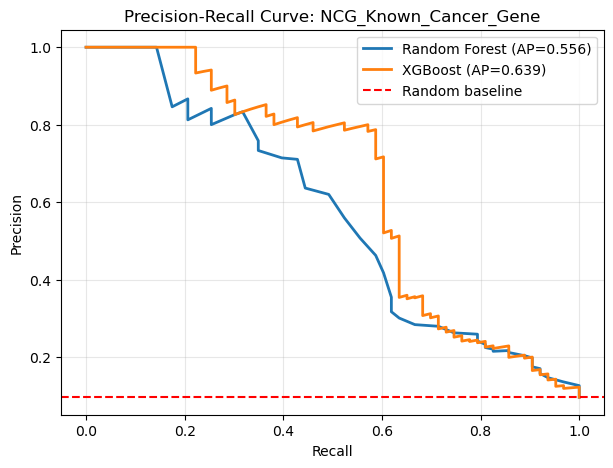

In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [14]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    2899
True      370
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:48:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


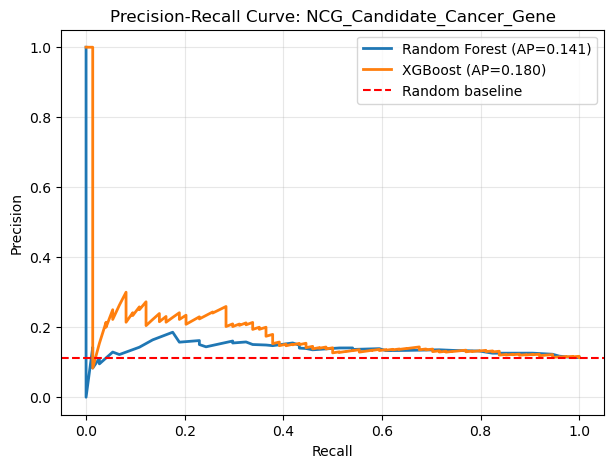

In [15]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [16]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    3016
True      253
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:48:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


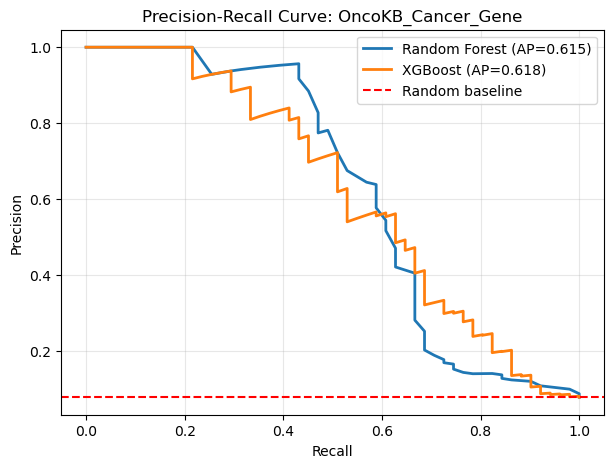

In [17]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [18]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    3134
True      135
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:48:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


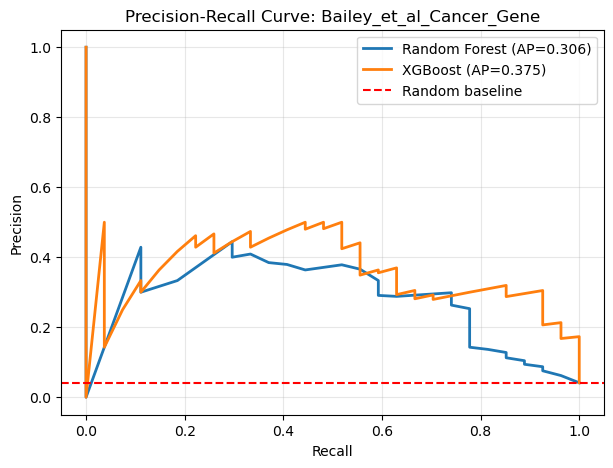

In [19]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')